<a href="https://colab.research.google.com/github/amiramazing/Fameli-Beta-Analysis/blob/main/Beta_and_correlation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#خواندن فایل شاخص و تبدیل ستون اول به فرمت استاندارد تاریخ
portfolio_df = pd.read_csv('Bourse_Index.csv')
portfolio_df['Date'] = pd.to_datetime(portfolio_df['Date'])
portfolio_df = portfolio_df[['Date', 'Market_Index']]

In [3]:
# --- این ۳ خط جدید هستند و حافظه را ریست می‌کنند ---
portfolio_df = pd.read_csv('Bourse_Index.csv')
portfolio_df['Date'] = pd.to_datetime(portfolio_df['Date'])
portfolio_df = portfolio_df[['Date', 'Market_Index']]
# ---------------------------------------------------

files = {
    'Fameli': 'Fameli_History.csv',
    'Khodro': 'Iran_Khodro_history_clean.csv',
    'Webmellat': 'Mellat_bank_history_clean.csv',
    'Shepna': 'S_Isf. Oil Ref.Co_history_clean.csv',
    'Ghapino': 'Ghapino_History_clean.csv'
}

for name, filename in files.items():
    df = pd.read_csv(filename)
    date_col, close_col = df.columns[0], df.columns[1]

    df['Date'] = pd.to_datetime(df[date_col].astype(str).str[:8], format='%Y%m%d', errors='coerce')
    df = df.rename(columns={close_col: f'{name}_Close'})

    # تغییر استراتژی از Inner به Left Join برای جلوگیری از حذف دیتای بازار
    portfolio_df = pd.merge(portfolio_df, df[['Date', f'{name}_Close']].dropna(), on='Date', how='left')

# پر کردن قیمت‌ها در روزهای بسته بودن سهم (توقف نماد) با آخرین قیمت معامله شده
portfolio_df = portfolio_df.ffill()

# حذف ردیف‌های ابتدایی (اگر سهمی دیرتر از بقیه عرضه اولیه شده باشد)
portfolio_df = portfolio_df.dropna().reset_index(drop=True)
print(f"✅ تعداد روزهای مشترک: {len(portfolio_df)}")

✅ تعداد روزهای مشترک: 1793


In [4]:
# ساخت ستون سال-ماه
portfolio_df['YearMonth'] = portfolio_df['Date'].dt.to_period('M')

# استخراج آخرین روز معاملاتی هر ماه
portfolio_monthly = portfolio_df.groupby('YearMonth').last().reset_index()

# محاسبه درصد بازدهی
columns_to_calc = ['Market_Index', 'Fameli_Close', 'Khodro_Close', 'Webmellat_Close', 'Shepna_Close', 'Ghapino_Close']

for col in columns_to_calc:
    if col in portfolio_monthly.columns:
        return_col_name = col.replace('_Index', '_Return').replace('_Close', '_Return')
        portfolio_monthly[return_col_name] = portfolio_monthly[col].pct_change()

# حذف ردیف اول (چون بازده ماه قبل را ندارد و NaN می‌شود)
portfolio_monthly = portfolio_monthly.dropna()
print("✅ بازده ماهانه محاسبه شد.")
portfolio_monthly.head()

✅ بازده ماهانه محاسبه شد.


,YearMonth,Date,Market_Index,Fameli_Close,Khodro_Close,Webmellat_Close,Shepna_Close,Ghapino_Close,Market_Return,Fameli_Return,Khodro_Return,Webmellat_Return,Shepna_Return,Ghapino_Return
1,2018-06,2018-06-29,111510.8,3479.0,2347.0,934.0,4778.0,2924.0,0.166703,0.337562,-0.026545,0.030905,0.153271,0.103396
2,2018-07,2018-07-31,123951.0,3322.0,2110.0,897.0,4817.0,2732.0,0.111560,-0.045128,-0.100980,-0.039615,0.008162,-0.065663
3,2018-08,2018-08-31,136109.0,4012.0,2419.0,1094.0,5521.0,2681.0,0.098087,0.207706,0.146445,0.219621,0.146149,-0.018668
4,2018-09,2018-09-30,195480.0,4740.0,3469.0,2064.0,9501.0,4075.0,0.436202,0.181456,0.434064,0.886654,0.720884,0.519955
5,2018-10,2018-10-30,183367.0,4302.0,2451.0,2472.0,9467.0,3119.0,-0.061965,-0.092405,-0.293456,0.197674,-0.003579,-0.234601


In [5]:
print("--- ضرایب بتا (Beta) ---")

market_var = portfolio_monthly['Market_Return'].var()
stock_returns = [c for c in portfolio_monthly.columns if '_Return' in c and 'Market' not in c]

betas = {}
for stock in stock_returns:
    cov = portfolio_monthly[stock].cov(portfolio_monthly['Market_Return'])
    beta = cov / market_var
    betas[stock.replace('_Return', '')] = beta
    print(f"{stock.replace('_Return', '')}: {beta:.2f}")

--- ضرایب بتا (Beta) ---
Fameli: 1.19
Khodro: 1.28
Webmellat: 0.89
Shepna: 1.52
Ghapino: 0.38


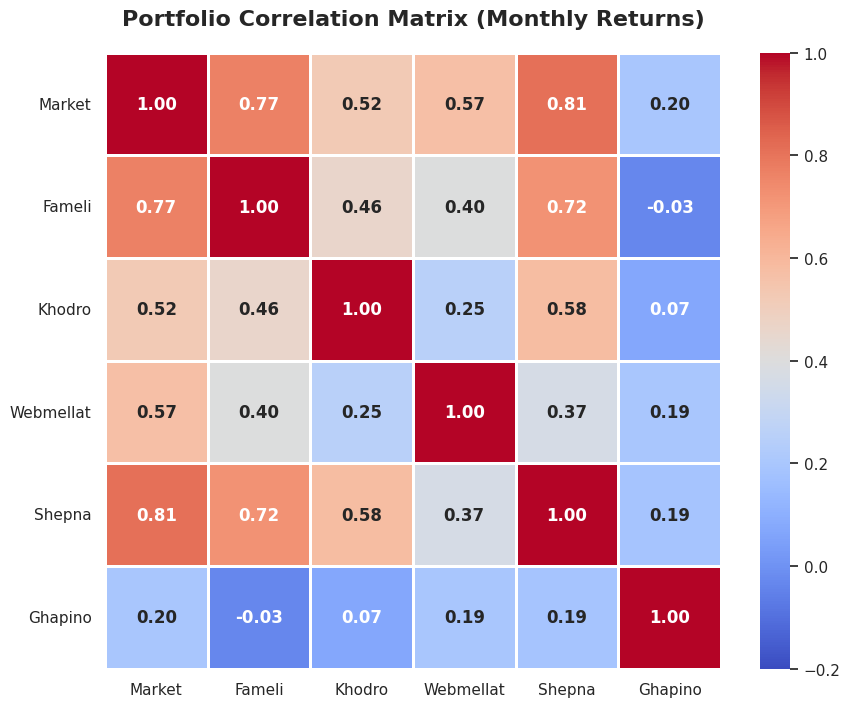

✅ نقشه حرارتی با موفقیت رسم و با نام 'Portfolio_Heatmap_Final.png' ذخیره شد!


In [6]:
return_columns = ['Market_Return'] + stock_returns
returns_df = portfolio_monthly[return_columns].copy()

# زیباسازی نام ستون‌ها برای نمایش در نمودار
returns_df.columns = [c.replace('_Return', '') for c in returns_df.columns]

plt.figure(figsize=(10, 8))
sns.set_theme(style="white")

# رسم هیت‌مپ
sns.heatmap(returns_df.corr(), annot=True, cmap='coolwarm', vmin=-0.2, vmax=1,
            fmt=".2f", linewidths=1, linecolor='white', square=True,
            annot_kws={"size": 12, "weight": "bold"})

plt.title("Portfolio Correlation Matrix (Monthly Returns)", fontsize=16, fontweight='bold', pad=20)
plt.yticks(rotation=0)

plt.savefig("Portfolio_Heatmap_Final.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ نقشه حرارتی با موفقیت رسم و با نام 'Portfolio_Heatmap_Final.png' ذخیره شد!")